In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi
from tqdm import tqdm
import time
import pickle

In [2]:
api = KaggleApi()
api.authenticate()

dataset_dir = Path("./dataset")

if dataset_dir.exists() and len(list(dataset_dir.glob("*.csv"))) == 1:
    print(f"Data already downloaded.")
else:
    api.dataset_download_files(
        'uciml/mushroom-classification',
        path=dataset_dir,
        unzip=True
    )

file = list(dataset_dir.glob("*.csv"))[0]

Data already downloaded.


In [3]:
df = pd.read_csv(file)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [5]:
from preprocessing_scripts import print_unique_values

print_unique_values(df)


Column: class
Number of unique values: 2
Unique values: <StringArray>
['p', 'e']
Length: 2, dtype: str

Column: cap-shape
Number of unique values: 6
Unique values: <StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str

Column: cap-surface
Number of unique values: 4
Unique values: <StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str

Column: cap-color
Number of unique values: 10
Unique values: <StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str

Column: bruises
Number of unique values: 2
Unique values: <StringArray>
['t', 'f']
Length: 2, dtype: str

Column: odor
Number of unique values: 9
Unique values: <StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str

Column: gill-attachment
Number of unique values: 2
Unique values: <StringArray>
['f', 'a']
Length: 2, dtype: str

Column: gill-spacing
Number of unique values: 2
Unique values: <StringArray>
['c', 'w']
Length: 2, dtype: str

Column: gill-size
Number of 

In [6]:
from preprocessing_scripts import map_features
from mappings import SHORT_TO_FULL

df_mapped = map_features(df, feature_mapping=SHORT_TO_FULL)
df_mapped

Mapping for feature 'gill-attachment' contains labels not present in data: {'d', 'n'}
Mapping for feature 'gill-spacing' contains labels not present in data: {'d'}
Mapping for feature 'stalk-root' contains labels not present in data: {'u', 'z'}
Mapping for feature 'veil-type' contains labels not present in data: {'u'}
Mapping for feature 'ring-type' contains labels not present in data: {'c', 'z', 's'}


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,poisonous,convex,smooth,brown,bruises,pungent,free,close,narrow,black,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
1,edible,convex,smooth,yellow,bruises,almond,free,close,broad,black,...,smooth,white,white,partial,white,one,pendant,brown,numerous,grasses
2,edible,bell,smooth,white,bruises,anise,free,close,broad,brown,...,smooth,white,white,partial,white,one,pendant,brown,numerous,meadows
3,poisonous,convex,scaly,white,bruises,pungent,free,close,narrow,brown,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
4,edible,convex,smooth,gray,no,none,free,crowded,broad,black,...,smooth,white,white,partial,white,one,evanescent,brown,abundant,grasses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,edible,knobbed,smooth,brown,no,none,attached,close,broad,yellow,...,smooth,orange,orange,partial,orange,one,pendant,buff,clustered,leaves
8120,edible,convex,smooth,brown,no,none,attached,close,broad,yellow,...,smooth,orange,orange,partial,brown,one,pendant,buff,several,leaves
8121,edible,flat,smooth,brown,no,none,attached,close,broad,brown,...,smooth,orange,orange,partial,orange,one,pendant,buff,clustered,leaves
8122,poisonous,knobbed,scaly,brown,no,fishy,free,close,narrow,buff,...,silky,white,white,partial,white,one,evanescent,white,several,leaves


In [7]:
df_mapped.eq("missing").sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [8]:
df_mapped.drop(columns="veil-type", inplace=True)
df_mapped.shape

(8124, 22)

In [9]:
df_mapped["gill-veil"] = df_mapped["gill-attachment"] + "_" + df_mapped["veil-color"]
df_mapped_cleaned = df_mapped.drop(columns=["gill-attachment", "veil-color"])
df_mapped_cleaned

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,ring-number,ring-type,spore-print-color,population,habitat,gill-veil
0,poisonous,convex,smooth,brown,bruises,pungent,close,narrow,black,enlarging,...,smooth,smooth,white,white,one,pendant,black,scattered,urban,free_white
1,edible,convex,smooth,yellow,bruises,almond,close,broad,black,enlarging,...,smooth,smooth,white,white,one,pendant,brown,numerous,grasses,free_white
2,edible,bell,smooth,white,bruises,anise,close,broad,brown,enlarging,...,smooth,smooth,white,white,one,pendant,brown,numerous,meadows,free_white
3,poisonous,convex,scaly,white,bruises,pungent,close,narrow,brown,enlarging,...,smooth,smooth,white,white,one,pendant,black,scattered,urban,free_white
4,edible,convex,smooth,gray,no,none,crowded,broad,black,tapering,...,smooth,smooth,white,white,one,evanescent,brown,abundant,grasses,free_white
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,edible,knobbed,smooth,brown,no,none,close,broad,yellow,enlarging,...,smooth,smooth,orange,orange,one,pendant,buff,clustered,leaves,attached_orange
8120,edible,convex,smooth,brown,no,none,close,broad,yellow,enlarging,...,smooth,smooth,orange,orange,one,pendant,buff,several,leaves,attached_brown
8121,edible,flat,smooth,brown,no,none,close,broad,brown,enlarging,...,smooth,smooth,orange,orange,one,pendant,buff,clustered,leaves,attached_orange
8122,poisonous,knobbed,scaly,brown,no,fishy,close,narrow,buff,tapering,...,smooth,silky,white,white,one,evanescent,white,several,leaves,free_white


In [10]:
X = df_mapped_cleaned.drop(columns=["class"])
y = df_mapped_cleaned["class"] 

In [11]:
X_one_hot = pd.get_dummies(X, dummy_na=False)
X_one_hot

,cap-shape_bell,cap-shape_conical,cap-shape_convex,cap-shape_flat,cap-shape_knobbed,cap-shape_sunken,cap-surface_fibrous,cap-surface_grooves,cap-surface_scaly,cap-surface_smooth,...,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,gill-veil_attached_brown,gill-veil_attached_orange,gill-veil_attached_white,gill-veil_free_white,gill-veil_free_yellow
0,False,False,True,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,True,False,False,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,False,False,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
8120,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
8121,False,False,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
8122,False,False,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [12]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_ord = pd.DataFrame(encoder.fit_transform(X), columns=X.columns)
X_ord

,cap-shape,cap-surface,cap-color,bruises,odor,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,ring-number,ring-type,spore-print-color,population,habitat,gill-veil
0,2.0,3.0,0.0,0.0,7.0,0.0,1.0,0.0,0.0,2.0,3.0,3.0,7.0,7.0,1.0,4.0,0.0,3.0,4.0,3.0
1,2.0,3.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,7.0,7.0,1.0,4.0,1.0,2.0,0.0,3.0
2,0.0,3.0,8.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,3.0,7.0,7.0,1.0,4.0,1.0,2.0,2.0,3.0
3,2.0,2.0,8.0,0.0,7.0,0.0,1.0,1.0,0.0,2.0,3.0,3.0,7.0,7.0,1.0,4.0,0.0,3.0,4.0,3.0
4,2.0,3.0,3.0,1.0,6.0,1.0,0.0,0.0,1.0,2.0,3.0,3.0,7.0,7.0,1.0,0.0,1.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,4.0,3.0,0.0,1.0,6.0,0.0,0.0,11.0,0.0,3.0,3.0,3.0,4.0,4.0,1.0,4.0,2.0,1.0,1.0,1.0
8120,2.0,3.0,0.0,1.0,6.0,0.0,0.0,11.0,0.0,3.0,3.0,3.0,4.0,4.0,1.0,4.0,2.0,4.0,1.0,0.0
8121,3.0,3.0,0.0,1.0,6.0,0.0,0.0,1.0,0.0,3.0,3.0,3.0,4.0,4.0,1.0,4.0,2.0,1.0,1.0,1.0
8122,4.0,2.0,0.0,1.0,3.0,0.0,1.0,2.0,1.0,3.0,3.0,2.0,7.0,7.0,1.0,0.0,7.0,4.0,1.0,3.0


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

array([1, 0, 0, ..., 0, 1, 0], shape=(8124,))

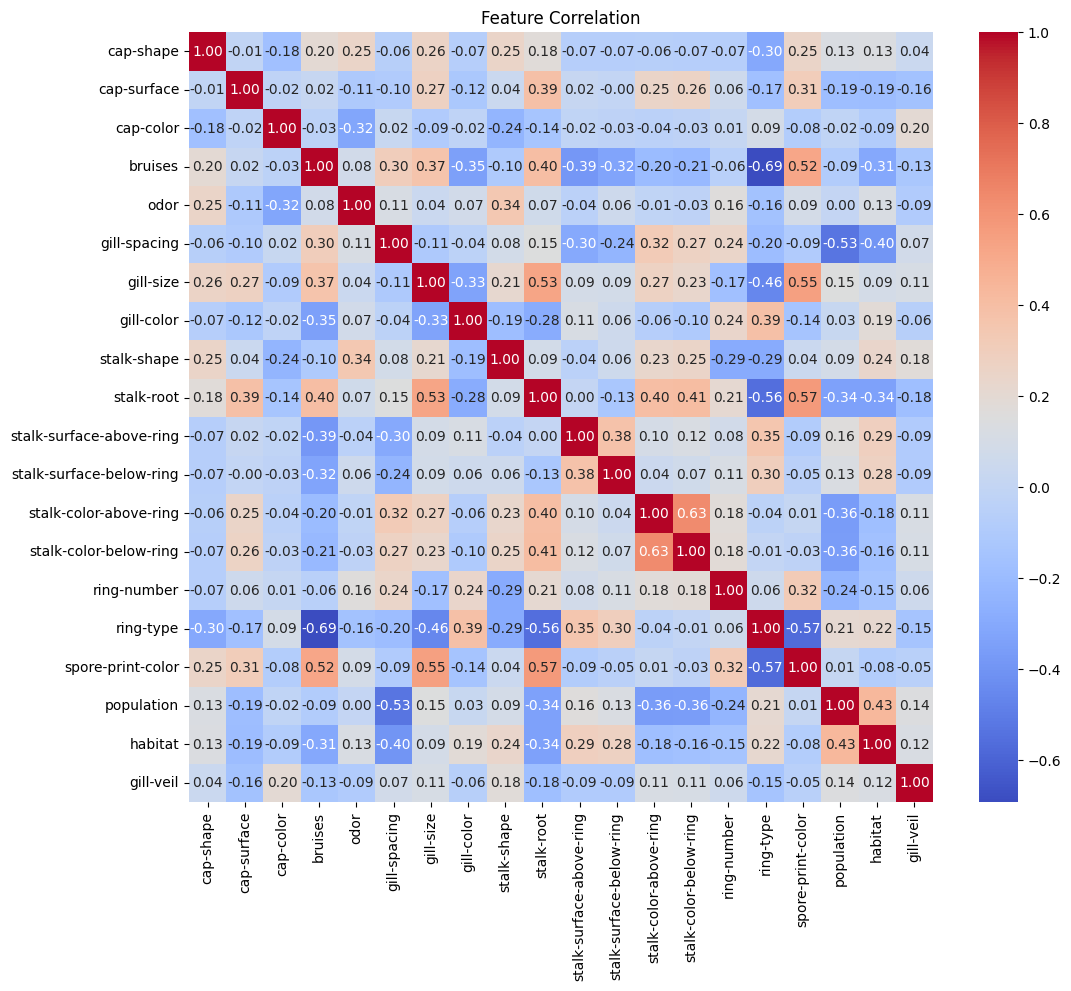

In [14]:
corr_matrix = X_ord.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ord,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

In [16]:
import numpy as np

print("Train class distribution:", np.bincount(y_train))
print("Test class distribution: ", np.bincount(y_test))

Train class distribution: [3366 3133]
Test class distribution:  [842 783]


In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [18]:
INTERPRETABILITY = {
    DecisionTreeClassifier: 5,
    LogisticRegression: 5,
    GaussianNB: 4,
    LinearDiscriminantAnalysis: 4,
    RidgeClassifier: 4,
    RandomForestClassifier: 3,
    ExtraTreesClassifier: 3,
    GradientBoostingClassifier: 2,
    AdaBoostClassifier: 2,
    SVC: 2,
    KNeighborsClassifier: 1,
}

def get_interpretability(model):
    return INTERPRETABILITY.get(type(model), 3)

In [19]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    # ---------- TRAIN TIME ----------
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    # ---------- INFERENCE TIME ----------
    start = time.perf_counter()
    y_pred = model.predict(X_test)
    inference_time = time.perf_counter() - start

    # ---------- METRICS ----------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC AUC if probabilities exist
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    except:
        roc_auc = None

    # ---------- CROSS VALIDATION ----------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv)

    # ---------- MODEL SIZE ----------
    model_bytes = len(pickle.dumps(model))
    model_size_kb = model_bytes / 1024

    latency = inference_time / len(X_test)
    throughput = len(X_test) / inference_time
    efficiency = accuracy / model_size_kb
    stability = 1 / cv_scores.std()


    return {
        "model": name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "train_time_sec": train_time,
        "inference_time_sec": inference_time,
        "model_size_kb": model_size_kb,
        "latency": latency,
        "throughput": throughput,
        "efficiency": efficiency,
        "stability": stability,
        "interpretability": get_interpretability(model),

    }

In [20]:
models = {

    # ================= TREE MODELS =================
    "DecisionTree_default":
        DecisionTreeClassifier(random_state=42),

    "DecisionTree_shallow":
        DecisionTreeClassifier(max_depth=5, random_state=42),

    "DecisionTree_pruned":
        DecisionTreeClassifier(min_samples_leaf=20, random_state=42),


    "RandomForest_small":
        RandomForestClassifier(
            n_estimators=50,
            n_jobs=-1,
            random_state=42
        ),

    "RandomForest_large":
        RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1,
            random_state=42
        ),

    "ExtraTrees_fast":
        ExtraTreesClassifier(
            n_estimators=50,
            n_jobs=-1,
            random_state=42
        ),

    "ExtraTrees_large":
        ExtraTreesClassifier(
            n_estimators=300,
            n_jobs=-1,
            random_state=42
        ),

    # ================= BOOSTING =================
    "GradientBoosting_fast":
        GradientBoostingClassifier(
            n_estimators=50,
            learning_rate=0.2,
            random_state=42
        ),

    "GradientBoosting_slow":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ),

    "AdaBoost_light":
        AdaBoostClassifier(
            n_estimators=50,
            random_state=42
        ),

    "AdaBoost_heavy":
        AdaBoostClassifier(
            n_estimators=300,
            random_state=42
        ),

    # ================= LINEAR =================
    "LogReg_strong_reg":
        LogisticRegression(
            C=0.1,
            max_iter=2000,
            n_jobs=-1,
            random_state=42
        ),

    "LogReg_weak_reg":
        LogisticRegression(
            C=10,
            max_iter=2000,
            n_jobs=-1,
            random_state=42
        ),

    "Ridge_alpha_small":
        RidgeClassifier(alpha=0.1),

    "Ridge_alpha_large":
        RidgeClassifier(alpha=10),

    # ================= PROBABILISTIC =================
    "GaussianNB_default":
        GaussianNB(),

    "GaussianNB_smoothed":
        GaussianNB(var_smoothing=1e-7),

    "LDA_svd":
        LinearDiscriminantAnalysis(solver="svd"),

    "LDA_lsqr":
        LinearDiscriminantAnalysis(solver="lsqr"),

    # ================= INSTANCE =================
    "KNN_3":
        KNeighborsClassifier(n_neighbors=3, n_jobs=-1),

    "KNN_15":
        KNeighborsClassifier(n_neighbors=15, n_jobs=-1),

    # ================= KERNEL =================
    "SVC_rbf":
        SVC(kernel="rbf", probability=True, random_state=42),

    "SVC_linear":
        SVC(kernel="linear", probability=True, random_state=42),

    "SVC_poly":
        SVC(kernel="poly", degree=3, probability=True, random_state=42),
}

In [21]:
results = []

for name, model in tqdm(models.items()):
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)

results_df = pd.DataFrame(results).sort_values(
    by="accuracy", ascending=False
)

results_df

  0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipykernel_93942/8156591.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  stability = 1 / cv_scores.std()
  8%|▊         | 2/24 [00:00<00:01, 16.87it/s]/tmp/ipykernel_93942/8156591.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  stability = 1 / cv_scores.std()
 17%|█▋        | 4/24 [00:01<00:07,  2.68it/s]/tmp/ipykernel_93942/8156591.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  stability = 1 / cv_scores.std()
 21%|██        | 5/24 [00:08<00:43,  2.29s/it]/tmp/ipykernel_93942/8156591.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  stability = 1 / cv_scores.std()
 25%|██▌       | 6/24 [00:09<00:35,  1.94s/it]/tmp/ipykernel_93942/8156591.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  stability = 1 / cv_scores.std()
 29%|██▉       | 7/24 [00:14<00:49,  2.93s/it]/tmp/ipykernel_93942/8156591.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  stability = 1 / cv_sco

,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std,train_time_sec,inference_time_sec,model_size_kb,latency,throughput,efficiency,stability,interpretability
0,DecisionTree_default,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.011072,0.001390,3.609375,8.554461e-07,1.168981e+06,0.277056,inf,5
3,RandomForest_small,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.161741,0.036613,219.852539,2.253087e-05,4.438355e+04,0.004549,inf,3
5,ExtraTrees_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.126455,0.038248,278.919922,2.353719e-05,4.248596e+04,0.003585,inf,3
4,RandomForest_large,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.958072,0.154101,1325.002930,9.483119e-05,1.054505e+04,0.000755,inf,3
6,ExtraTrees_large,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.752401,0.155814,1701.605469,9.588524e-05,1.042913e+04,0.000588,inf,3
7,GradientBoosting_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.252880,0.002336,69.969727,1.437576e-06,6.956154e+05,0.014292,inf,2
10,AdaBoost_heavy,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.930634,0.050983,163.905273,3.137389e-05,3.187364e+04,0.006101,inf,2
8,GradientBoosting_slow,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.916217,0.004814,261.228516,2.962428e-06,3.375610e+05,0.003828,inf,2
23,SVC_poly,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.792256,0.019619,45.899414,1.207338e-05,8.282682e+04,0.021787,inf,2
19,KNN_3,1.000000,1.000000,1.000000,1.000000,1.000000,0.999385,0.001231,0.002203,0.063479,1067.291992,3.906418e-05,2.559890e+04,0.000937,812.500000,1


In [22]:
results_df.to_csv("./models_metrics.csv")